In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr

sys.path.insert(0, '..')  # dataset.py lives one level up, shared across experiment types
import dataset
import forecast_train

from investalyze.analysis import encodings
from investalyze.ingest import storage

plt.rcParams['figure.dpi'] = 130

In [2]:
TICKERS = 2000  # list[str] of specific tickers, int for a random sample of that many, or None for all
EXCLUDE_TICKERS = ['LITX', 'PCG-PD']  # tickers to always leave out, regardless of TICKERS
SEED = 0  # used when TICKERS is an int, and when VALID_METHOD is 'random'
WINDOW_LENGTH = 30
STRIDE = 15
HORIZON = 5  # trading days ahead to forecast the return over

VALID_FRAC = 0.3
VALID_METHOD = 'random'  # 'recent' = time-based (no leakage) / 'random' = random per-window
TEST_N = 5  # always recent: the last N windows of each ticker

ENCODER = encodings.zscore  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax

N_ESTIMATORS = 500  # boosting rounds (upper bound; early stopping picks the best)
MAX_DEPTH = 24
LEARNING_RATE = 0.1
EARLY_STOPPING_ROUNDS = 50  # stop if valid rmse hasn't improved in this many rounds
N_JOBS = -1

In [3]:
DATA_ROOT = Path('../../../data')

con = storage.connect(DATA_ROOT, read_only=True)
tickers = dataset.sample_tickers(con, TICKERS, seed=SEED, exclude=EXCLUDE_TICKERS) if isinstance(TICKERS, int) else TICKERS
series = dataset.get_ohlcv_series(con, tickers, exclude=EXCLUDE_TICKERS)
con.close()
print('tickers used', tickers if tickers is not None else 'ALL')

channels, meta = dataset.build_windows_with_future_return(series, window_length=WINDOW_LENGTH, stride=STRIDE, horizon=HORIZON)
print('windows', meta.shape[0], 'across', meta['Ticker'].nunique(), 'tickers')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

tickers used ['AA', 'AACB', 'AACIU', 'AAPG', 'AAPL', 'AARD', 'AB', 'ABFL', 'ABLG', 'ABLS', 'ABLVW', 'ABOT', 'ABR-PE', 'ABT', 'ABTC', 'ABUF', 'ABUS', 'ABVX', 'ACAA', 'ACB', 'ACEL', 'ACI', 'ACIW', 'ACLX', 'ACMR', 'ACNT', 'ACOG', 'ACON', 'ACP-PA', 'ACR', 'ACR-PC', 'ACRV', 'ACT', 'ACTG', 'ADAC', 'ADAM', 'ADAMH', 'ADEA', 'ADIL', 'AEAQU', 'AEE', 'AEFC', 'AEG', 'AEHL', 'AEIS', 'AEON', 'AEP', 'AESI', 'AFBI', 'AFGD', 'AFJK', 'AFJKU', 'AFL', 'AGH', 'AGI', 'AGNCO', 'AGO', 'AGRZ', 'AGYS', 'AHL-PF', 'AIBU', 'AIDX', 'AIG', 'AIHS', 'AIM', 'AIMD', 'AIOS', 'AIR', 'AIRG', 'AIRO', 'AIRTP', 'AIV', 'AKAN', 'AKBA', 'AKTX', 'ALAB', 'ALB', 'ALC', 'ALCO', 'ALDFU', 'ALDX', 'ALH', 'ALLR', 'ALRM', 'ALRS', 'ALTG', 'ALVO', 'ALZN', 'AMA', 'AMBA', 'AMD', 'AMH', 'AMH-PG', 'AMH-PH', 'AMIX', 'AMT', 'AMTD', 'AMYY', 'AMZW', 'AN', 'ANG-PD', 'ANGHW', 'ANY', 'AOMR', 'AOUT', 'AP', 'APG', 'APH', 'APLD', 'APO-PA', 'APPN', 'APT', 'APTV', 'APVO', 'APXT', 'AQLT', 'AQN', 'AQST', 'ARAI', 'ARCT', 'ARDC', 'ARDX', 'AREC', 'ARHS', 'ARR-

In [4]:
train_mask, valid_mask, test_mask = dataset.split_windows(meta, valid_frac=VALID_FRAC, valid_method=VALID_METHOD, test_n=TEST_N, seed=SEED)
meta['excess_return'] = dataset.demean_by_date(meta, 'future_return')

print('train windows', int(train_mask.sum()), 'valid windows', int(valid_mask.sum()), 'test windows', int(test_mask.sum()))
group_sizes = meta.groupby('end_date').size()
print('cross-sectional group size: median', int(group_sizes.median()), 'max', int(group_sizes.max()))
meta['excess_return'].describe()

train windows 268753 valid windows 115315 test windows 8660
cross-sectional group size: median 210 max 1728


count    3.948680e+05
mean    -2.159332e-19
std      1.111436e-01
min     -9.895192e-01
25%     -2.660359e-02
50%     -2.513625e-03
75%      2.202096e-02
max      3.657157e+01
Name: excess_return, dtype: float64

In [6]:
X = dataset.encode_windows(channels, ENCODER)
X_flat = dataset.flatten_windows(X)
y = meta['excess_return'].to_numpy()
end_dates = meta['end_date'].to_numpy()

X_train, y_train = X_flat[train_mask], y[train_mask]
X_valid, y_valid = X_flat[valid_mask], y[valid_mask]
X_test, y_test = X_flat[test_mask], y[test_mask]
dates_valid, dates_test = end_dates[valid_mask], end_dates[test_mask]

In [7]:
reg = xgb.XGBRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    tree_method='hist',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    eval_metric='rmse',
    n_jobs=N_JOBS,
)
reg.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
print('best iteration', reg.best_iteration, '/', N_ESTIMATORS)

best iteration 0 / 500


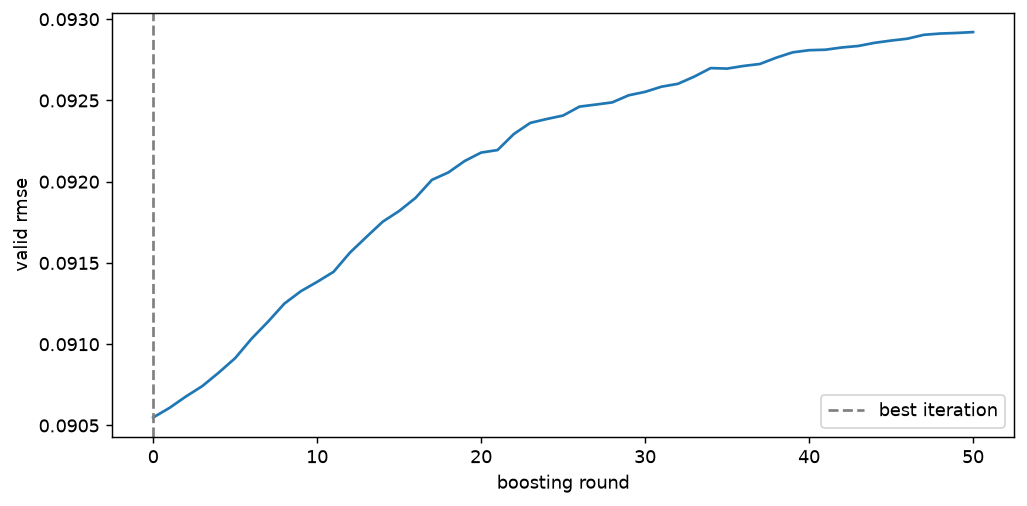

In [8]:
valid_rmse = reg.evals_result()['validation_0']['rmse']
plt.figure(figsize=(8, 4))
plt.plot(valid_rmse)
plt.axvline(reg.best_iteration, color='gray', linestyle='--', label='best iteration')
plt.xlabel('boosting round')
plt.ylabel('valid rmse')
plt.legend()
plt.tight_layout()
plt.show()

/mnt/Dev/active_python_projects/investalyze/experiments/ticker_classification/forecast_excess_return/forecast_train.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(preds[mask], targets[mask])


valid: global spearman=0.0166  per-date spearman=0.0138


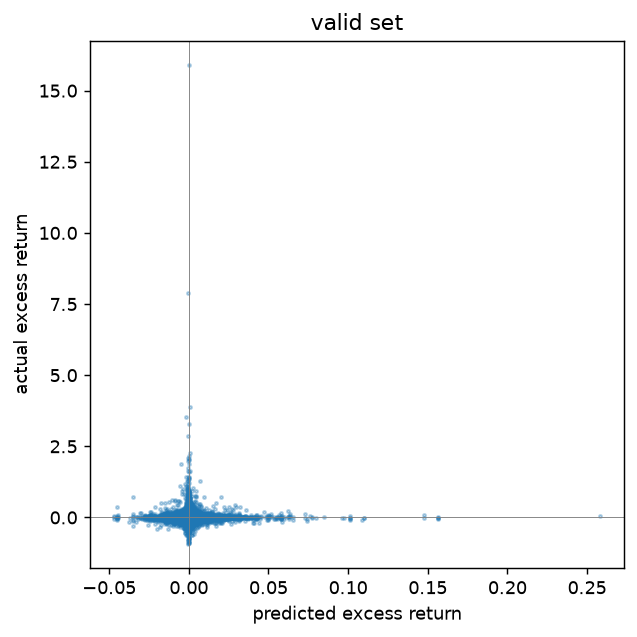

In [9]:
valid_preds = reg.predict(X_valid)
valid_corr_global = spearmanr(valid_preds, y_valid).statistic
valid_corr_grouped = forecast_train.spearman_by_group(valid_preds, y_valid, dates_valid)
print(f'valid: global spearman={valid_corr_global:.4f}  per-date spearman={valid_corr_grouped:.4f}')

plt.figure(figsize=(5, 5))
plt.scatter(valid_preds, y_valid, s=3, alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('predicted excess return')
plt.ylabel('actual excess return')
plt.title('valid set')
plt.tight_layout()
plt.show()

test: global spearman=0.0192  per-date spearman=0.1261


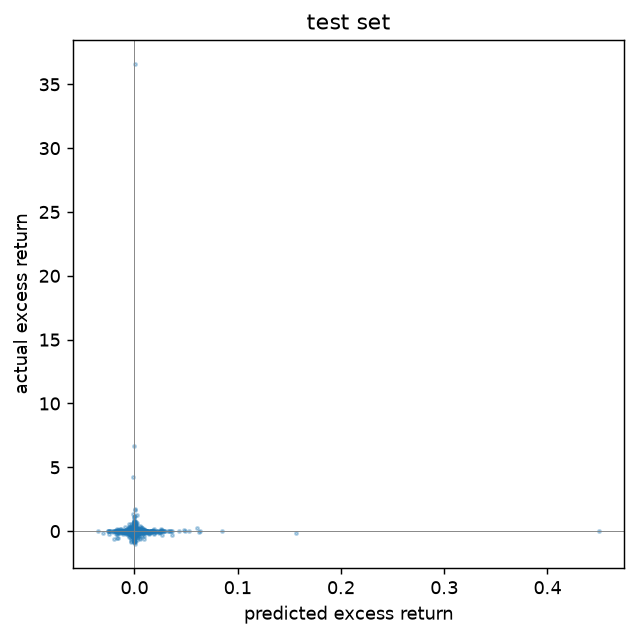

In [10]:
test_preds = reg.predict(X_test)
test_corr_global = spearmanr(test_preds, y_test).statistic
test_corr_grouped = forecast_train.spearman_by_group(test_preds, y_test, dates_test)
print(f'test: global spearman={test_corr_global:.4f}  per-date spearman={test_corr_grouped:.4f}')

plt.figure(figsize=(5, 5))
plt.scatter(test_preds, y_test, s=3, alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('predicted excess return')
plt.ylabel('actual excess return')
plt.title('test set')
plt.tight_layout()
plt.show()